# 📘 Notebook 1: Data Loading & Quality Control

**Mục tiêu:** *"Dữ liệu của tôi có sạch không? Tôi có bao nhiêu mẫu thực sự dùng được?"*

Notebook này đào sâu vào từng file `iteration_data.csv` để lấy số liệu **thực tế cuối cùng**, thay vì tin tưởng hoàn toàn vào `_all_summaries_parallel.json`.

### Các phân tích chính:
1. Quét và gom dữ liệu từ toàn bộ cây thư mục Phase 1
2. Đánh giá hội tụ (convergence) — phân phối số iterations
3. Phát hiện Void Collapse — tỷ lệ mẫu có Volume_Fraction < 0.01
4. Kiểm tra tính hợp lý của nu12 — lọc giá trị ngoài khoảng (-1, 0.5)
5. Xuất manifest chi tiết dưới dạng Parquet

In [14]:
# ── Setup & Imports ──
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add notebooks dir to path so we can import utils
sys.path.insert(0, str(Path.cwd() / "notebooks"))
import utils

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

print("Imports loaded successfully.")
print(f"Phase 1 directory: {utils.PHASE1_DIR}")

Imports loaded successfully.
Phase 1 directory: ../outputs/pipeline/phase1


---
## 1. Quét và Gom dữ liệu

Duyệt qua tất cả seed/sample directories → đọc dòng cuối của `iteration_data.csv` + `metadata.json`

In [15]:
# ── Load all samples into a master DataFrame ──
df_raw = utils.load_all_samples()
print(f"Total samples loaded: {len(df_raw)}")
print(f"Columns: {list(df_raw.columns)}")
df_raw.head()

Total samples loaded: 300
Columns: ['sample_path', 'seed', 'sample_id', 'final_nu12', 'final_nu21', 'final_obj', 'final_VF', 'n_iter', 'converged_flag', 'void_flag', 'nu_valid_flag', 'volfrac', 'penal', 'rmin', 'move', 'void_size_frac', 'rotation_deg', 'mu']


,sample_path,seed,sample_id,final_nu12,final_nu21,final_obj,final_VF,n_iter,converged_flag,void_flag,nu_valid_flag,volfrac,penal,rmin,move,void_size_frac,rotation_deg,mu
0,../outputs/pipeline/phase1/circle/auxetic/samp...,circle,sample_0000,0.271527,0.271527,0.182620,0.493013,149,False,False,True,0.493014,4.008150,3.856900,0.144189,0.199058,48.073133,0.2
1,../outputs/pipeline/phase1/circle/auxetic/samp...,circle,sample_0001,0.300000,0.300000,-0.350459,0.253185,45,True,False,True,0.253185,2.495191,1.145314,0.062913,0.356292,18.219705,0.2
2,../outputs/pipeline/phase1/circle/auxetic/samp...,circle,sample_0002,0.301010,0.300002,-0.776576,0.588082,149,False,False,True,0.588082,2.756965,2.259431,0.239773,0.304454,44.808548,0.2
3,../outputs/pipeline/phase1/circle/auxetic/samp...,circle,sample_0003,0.309823,0.309823,-0.474882,0.505632,149,False,False,True,0.505632,1.715778,5.206985,0.272046,0.290293,39.320637,0.2
4,../outputs/pipeline/phase1/circle/auxetic/samp...,circle,sample_0004,0.299999,0.299999,-0.080289,0.359621,112,True,False,True,0.359622,3.774048,4.755546,0.282968,0.278457,12.950853,0.2


In [16]:
# ── Summary by seed ──
summary = df_raw.groupby("seed").agg(
    n_samples=("final_nu12", "count"),
    nu12_mean=("final_nu12", "mean"),
    nu12_median=("final_nu12", "median"),
    nu12_std=("final_nu12", "std"),
    VF_mean=("final_VF", "mean"),
    converged=("converged_flag", "sum"),
    void=("void_flag", "sum"),
).round(4)
summary

,n_samples,nu12_mean,nu12_median,nu12_std,VF_mean,converged,void
seed,,,,,,,
circle,30,0.3128,0.3005,0.0313,0.4493,14,0
circle_half_quarter,30,0.3077,0.3000,0.0237,0.4500,13,0
cross_rectangular,30,0.3098,0.3000,0.0370,0.4493,20,0
four_circle,30,0.3190,0.3002,0.0330,0.4494,10,0
grid_circular_voids,30,0.3173,0.3013,0.0400,0.4500,6,0
hexagonal,30,0.3046,0.3000,0.0294,0.4500,12,0
hourglass,30,0.3154,0.3000,0.0526,0.4500,14,0
nine_circle,30,0.3173,0.3013,0.0400,0.4500,6,0
small_square_cross,30,0.3113,0.3006,0.0233,0.4500,14,0


---
## 2. Đánh giá Hội tụ (Convergence)

Kiểm tra `n_iter` có đạt `max_iter` (150) hay dừng sớm do `change` không.

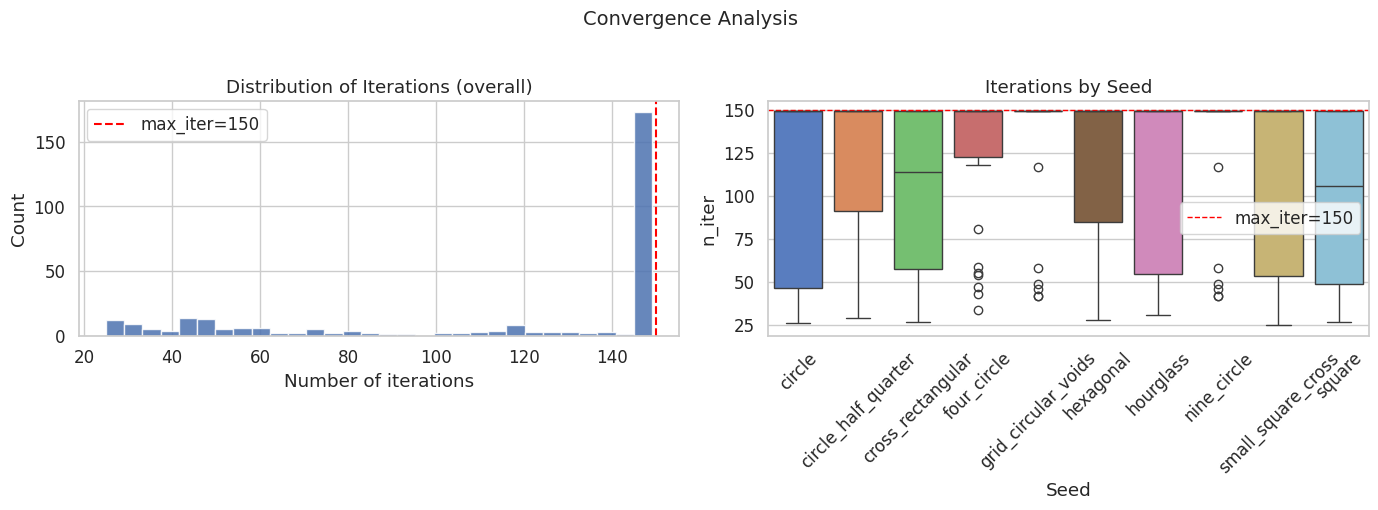

Converged early (n_iter < 150): 43.0% of samples


In [17]:
# ── Distribution of n_iter ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram overall
ax = axes[0]
ax.hist(df_raw["n_iter"].dropna(), bins=30, color="#4c72b0", edgecolor="white", alpha=0.85)
ax.axvline(utils.MAX_ITER, color="red", ls="--", lw=1.5, label=f"max_iter={utils.MAX_ITER}")
ax.set_xlabel("Number of iterations")
ax.set_ylabel("Count")
ax.set_title("Distribution of Iterations (overall)")
ax.legend()

# Boxplot by seed
ax = axes[1]
df_plot = df_raw.dropna(subset=["n_iter"])
sns.boxplot(data=df_plot, x="seed", y="n_iter", ax=ax, palette="muted")
ax.axhline(utils.MAX_ITER, color="red", ls="--", lw=1, label=f"max_iter={utils.MAX_ITER}")
ax.set_xlabel("Seed")
ax.set_ylabel("n_iter")
ax.set_title("Iterations by Seed")
ax.tick_params(axis="x", rotation=45)
ax.legend()

fig.suptitle("Convergence Analysis", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

# Stats
converged_rate = df_raw["converged_flag"].mean() * 100
print(f"Converged early (n_iter < {utils.MAX_ITER}): {converged_rate:.1f}% of samples")

In [18]:
# ── Convergence per seed (detailed table) ──
conv_summary = df_raw.groupby("seed").agg(
    total=("converged_flag", "count"),
    converged=("converged_flag", "sum"),
    not_converged=("converged_flag", lambda x: (~x.astype(bool)).sum()),
    mean_n_iter=("n_iter", "mean"),
    min_n_iter=("n_iter", "min"),
    max_n_iter=("n_iter", "max"),
).round(1)
conv_summary["converge_rate(%)"] = (conv_summary["converged"] / conv_summary["total"] * 100).round(1)
conv_summary

,total,converged,not_converged,mean_n_iter,min_n_iter,max_n_iter,converge_rate(%)
seed,,,,,,,
circle,30,14,16,111.5,26,149,46.7
circle_half_quarter,30,13,17,120.3,29,149,43.3
cross_rectangular,30,20,10,102.1,27,149,66.7
four_circle,30,10,20,124.9,34,149,33.3
grid_circular_voids,30,6,24,131.0,42,149,20.0
hexagonal,30,12,18,116.6,28,149,40.0
hourglass,30,14,16,106.2,31,149,46.7
nine_circle,30,6,24,131.0,42,149,20.0
small_square_cross,30,14,16,108.3,25,149,46.7


---
## 3. Phát hiện Void Collapse

Nếu `Volume_Fraction` cuối cùng < 0.01 → đánh dấu là VOID (bỏ qua).

In [19]:
# ── Void ratio ──
void_counts = df_raw.groupby("seed")["void_flag"].agg(["count", "sum"])
void_counts.columns = ["total", "void"]
void_counts["void_rate(%)"] = (void_counts["void"] / void_counts["total"] * 100).round(1)
void_counts

print(f"\nOverall void rate: {df_raw['void_flag'].mean() * 100:.1f}%")
print(f"Samples classified as VOID: {df_raw['void_flag'].sum()}")


Overall void rate: 0.0%
Samples classified as VOID: 0


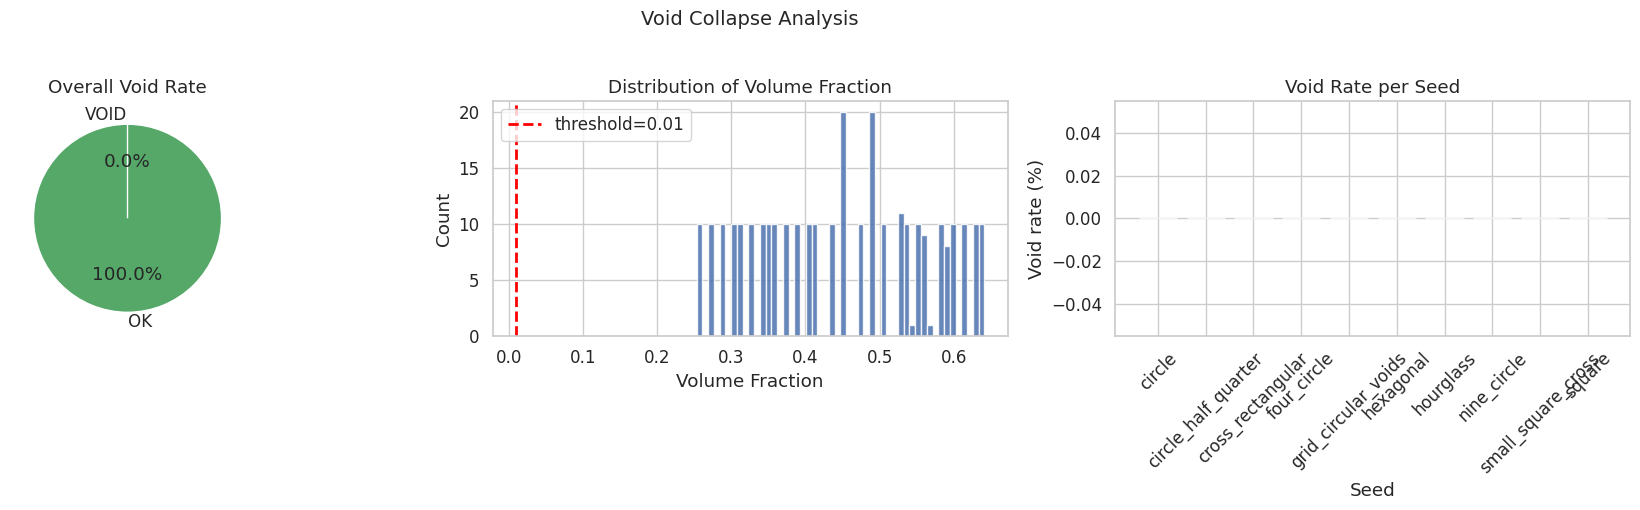

In [20]:
# ── Pie chart: void vs OK ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Overall
labels = ["OK", "VOID"]
sizes = [
    (~df_raw["void_flag"]).sum(),
    df_raw["void_flag"].sum(),
]
colors = ["#55a868", "#c44e52"]
axes[0].pie(sizes, labels=labels, autopct="%1.1f%%", colors=colors, startangle=90)
axes[0].set_title("Overall Void Rate")

# Volume_Fraction histogram
ax = axes[1]
ax.hist(df_raw["final_VF"].dropna(), bins=50, color="#4c72b0", edgecolor="white", alpha=0.85)
ax.axvline(utils.VOID_THRESHOLD, color="red", ls="--", lw=2, label=f"threshold={utils.VOID_THRESHOLD}")
ax.set_xlabel("Volume Fraction")
ax.set_ylabel("Count")
ax.set_title("Distribution of Volume Fraction")
ax.legend()

# Void rate per seed (bar)
ax = axes[2]
void_pct = (void_counts["void"] / void_counts["total"] * 100).sort_values(ascending=False)
ax.bar(void_pct.index, void_pct.values, color="#c44e52", alpha=0.8)
ax.set_xlabel("Seed")
ax.set_ylabel("Void rate (%)")
ax.set_title("Void Rate per Seed")
ax.tick_params(axis="x", rotation=45)

fig.suptitle("Void Collapse Analysis", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

---
## 4. Kiểm tra tính hợp lý của nu12

Đảm bảo `Poisson_v12` nằm trong khoảng vật lý (-1, 0.5).

In [21]:
# ── nu12 validity ──
total = len(df_raw)
valid = df_raw["nu_valid_flag"].sum()
invalid = total - valid
print(f"Total samples: {total}")
print(f"nu12 valid (-1 < nu < 0.5): {valid} ({valid/total*100:.1f}%)")
print(f"nu12 invalid (out-of-range or NaN): {invalid} ({invalid/total*100:.1f}%)")

# Show invalid details
df_invalid = df_raw[~df_raw["nu_valid_flag"]].copy()
print(f"\n--- Invalid samples (first 10) ---")
if len(df_invalid) > 0:
    display(df_invalid[["seed", "sample_id", "final_nu12", "final_nu21", "void_flag"]].head(10))

Total samples: 300
nu12 valid (-1 < nu < 0.5): 297 (99.0%)
nu12 invalid (out-of-range or NaN): 3 (1.0%)

--- Invalid samples (first 10) ---


,seed,sample_id,final_nu12,final_nu21,void_flag
132,grid_circular_voids,sample_0012,0.508041,0.344267,False
192,hourglass,sample_0012,0.503691,0.306121,False
222,nine_circle,sample_0012,0.508041,0.344267,False


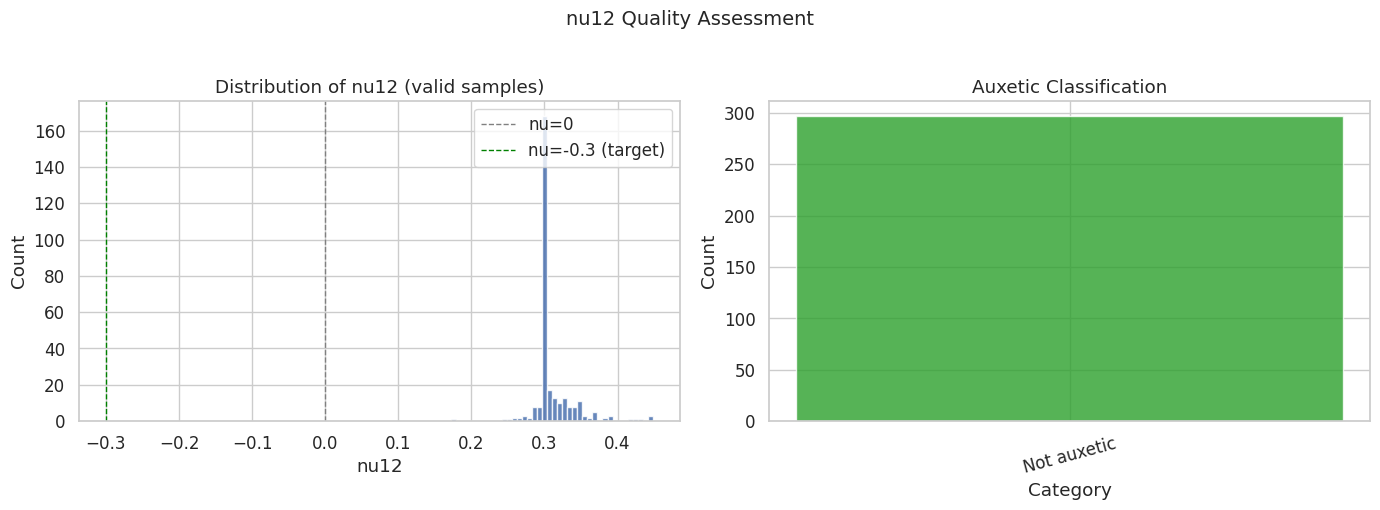


Classification breakdown:
auxetic_class
Not auxetic    297
Name: count, dtype: int64


In [22]:
# ── Histogram of nu12 (valid only) ──
df_valid = df_raw[df_raw["nu_valid_flag"]].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(df_valid["final_nu12"].dropna(), bins=40, color="#4c72b0", edgecolor="white", alpha=0.85)
ax.axvline(0, color="gray", ls="--", lw=1, label="nu=0")
ax.axvline(-0.3, color="green", ls="--", lw=1, label="nu=-0.3 (target)")
ax.set_xlabel("nu12")
ax.set_ylabel("Count")
ax.set_title("Distribution of nu12 (valid samples)")
ax.legend()

ax = axes[1]
df_valid["auxetic_class"] = df_valid["final_nu12"].apply(utils.classify_auxetic_quality)
class_counts = df_valid["auxetic_class"].value_counts()
colors_class = ["#2ca02c", "#ff7f0e", "#1f77b4", "#d62728"]
ax.bar(class_counts.index, class_counts.values, color=colors_class[:len(class_counts)], alpha=0.8)
ax.set_xlabel("Category")
ax.set_ylabel("Count")
ax.set_title("Auxetic Classification")
ax.tick_params(axis="x", rotation=15)

fig.suptitle("nu12 Quality Assessment", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

print("\nClassification breakdown:")
print(class_counts)

---
## 5. Xuất manifest chi tiết

Lưu DataFrame đã làm sạch thành `cleaned_dataset.parquet`.

In [23]:
# ── Select columns for export ──
export_cols = [
    "sample_path", "seed", "sample_id",
    "final_nu12", "final_nu21", "final_VF", "final_obj", "n_iter",
    "converged_flag", "void_flag", "nu_valid_flag",
    "volfrac", "penal", "rmin", "move", "void_size_frac", "rotation_deg", "mu",
]
df_export = df_raw[export_cols].copy()

# Save as Parquet
output_path = Path.cwd() / "cleaned_dataset.parquet"
df_export.to_parquet(output_path, index=False)
print(f"Saved cleaned dataset to: {output_path}")
print(f"Shape: {df_export.shape}")
print(f"Size: {output_path.stat().st_size / 1024:.1f} KB")

# Also save a small CSV preview
csv_preview_path = Path.cwd() / "cleaned_dataset_preview.csv"
df_export.head(20).to_csv(csv_preview_path, index=False)
print(f"Preview saved to: {csv_preview_path}")

df_export.head()

Saved cleaned dataset to: /home/tbm/Documents/Input_SIMP_Analyst/notebooks/cleaned_dataset.parquet
Shape: (300, 18)
Size: 22.4 KB
Preview saved to: /home/tbm/Documents/Input_SIMP_Analyst/notebooks/cleaned_dataset_preview.csv


,sample_path,seed,sample_id,final_nu12,final_nu21,final_VF,final_obj,n_iter,converged_flag,void_flag,nu_valid_flag,volfrac,penal,rmin,move,void_size_frac,rotation_deg,mu
0,../outputs/pipeline/phase1/circle/auxetic/samp...,circle,sample_0000,0.271527,0.271527,0.493013,0.182620,149,False,False,True,0.493014,4.008150,3.856900,0.144189,0.199058,48.073133,0.2
1,../outputs/pipeline/phase1/circle/auxetic/samp...,circle,sample_0001,0.300000,0.300000,0.253185,-0.350459,45,True,False,True,0.253185,2.495191,1.145314,0.062913,0.356292,18.219705,0.2
2,../outputs/pipeline/phase1/circle/auxetic/samp...,circle,sample_0002,0.301010,0.300002,0.588082,-0.776576,149,False,False,True,0.588082,2.756965,2.259431,0.239773,0.304454,44.808548,0.2
3,../outputs/pipeline/phase1/circle/auxetic/samp...,circle,sample_0003,0.309823,0.309823,0.505632,-0.474882,149,False,False,True,0.505632,1.715778,5.206985,0.272046,0.290293,39.320637,0.2
4,../outputs/pipeline/phase1/circle/auxetic/samp...,circle,sample_0004,0.299999,0.299999,0.359621,-0.080289,112,True,False,True,0.359622,3.774048,4.755546,0.282968,0.278457,12.950853,0.2


---
## 📋 Tổng kết Notebook 1

In [24]:
# ── Final summary ──
print("=" * 60)
print("  NOTEBOOK 1 — DATA LOADING & QUALITY CONTROL")
print("=" * 60)
print(f"  • Total samples scanned:     {len(df_raw)}")
print(f"  • Seeds covered:             {df_raw['seed'].nunique()}")
print(f"  • Converged early:           {converged_rate:.1f}%")
print(f"  • Void collapse rate:        {df_raw['void_flag'].mean()*100:.1f}%")
print(f"  • nu12 valid rate:           {valid/total*100:.1f}%")
print(f"  • Samples with nu12 < -0.3:  {(df_valid['final_nu12'] < -0.3).sum()}")
print(f"  • Samples with nu12 < -0.5:  {(df_valid['final_nu12'] < -0.5).sum()}")
print("=" * 60)
print("\n✅ Cleaned dataset exported to: notebooks/cleaned_dataset.parquet")

  NOTEBOOK 1 — DATA LOADING & QUALITY CONTROL
  • Total samples scanned:     300
  • Seeds covered:             10
  • Converged early:           43.0%
  • Void collapse rate:        0.0%
  • nu12 valid rate:           99.0%
  • Samples with nu12 < -0.3:  0
  • Samples with nu12 < -0.5:  0

✅ Cleaned dataset exported to: notebooks/cleaned_dataset.parquet
